<h1> VUDS Tracing Files Neural Network Indexed by Expected Bladder Capacity

In [2]:
## Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn import metrics
from sklearn.model_selection import train_test_split
from tensorflow import keras
from sklearn.compose import make_column_transformer
from sklearn import preprocessing
import sklearn
import pandas as pd
from collections import defaultdict, Counter
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

<h2>
This is the analysis and model for the tracing files (text files), that are indexed by %expected bladder capacity(ebc). Each file is received in .txt format and then converted to .csv 
<br><br>
The flow sheet(Clinical features) contains the data required for converting  the index to ebc%





In [3]:
# The redcap file to extract bladder cap
df = pd.read_csv('VUDS_aim1_master.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')


In [36]:
### You can also indicate another working directory here if the files are stored elsewhere.
path = os.getcwd()
files = os.listdir(path)

In [37]:
files_txt = [f for f in files if f[-3:] =="txt"]  # getting text files

In [38]:
len(files_txt)

307

<b> Visualizing a text file to demonstrate the difference between normalizing by time and pressure

In [31]:
dftest = pd.read_csv('VUDS-181.txt',sep='\t')
dftest

,Time,Pabd,Pves,IH2O,VH2O,Pdet,EMG2_A
0,0.0,0.2,-1.0,0.0,0.0,-1.2,8.6
1,0.1,0.2,-1.1,0.0,0.0,-1.3,8.2
2,0.2,0.3,-0.4,0.0,0.0,-0.7,8.0
3,0.3,0.5,-0.8,0.0,0.0,-1.2,8.3
4,0.4,0.4,-0.3,0.0,0.0,-0.7,6.0
...,...,...,...,...,...,...,...
17796,29:39.6,0.0,18.7,15.0,431.5,18.7,7.1
17797,29:39.7,-0.3,19.2,15.0,431.6,19.5,7.4
17798,29:39.8,-0.3,18.3,15.0,431.6,18.5,6.9
17799,29:39.9,-0.3,21.0,15.0,431.6,21.2,7.2


<b>
The text files need to be normalized as each patient has a wide range of time that a VUDS is completed. A previous study truncated the time range at 10 minutes. Note in the example below if we were to truncate at 10 minutes this sample would lose a lot of information and the rise that occurs later during the VUDS. However very few patient’s procedures take as long as this example. This is why normalizing to %EBC is superior.

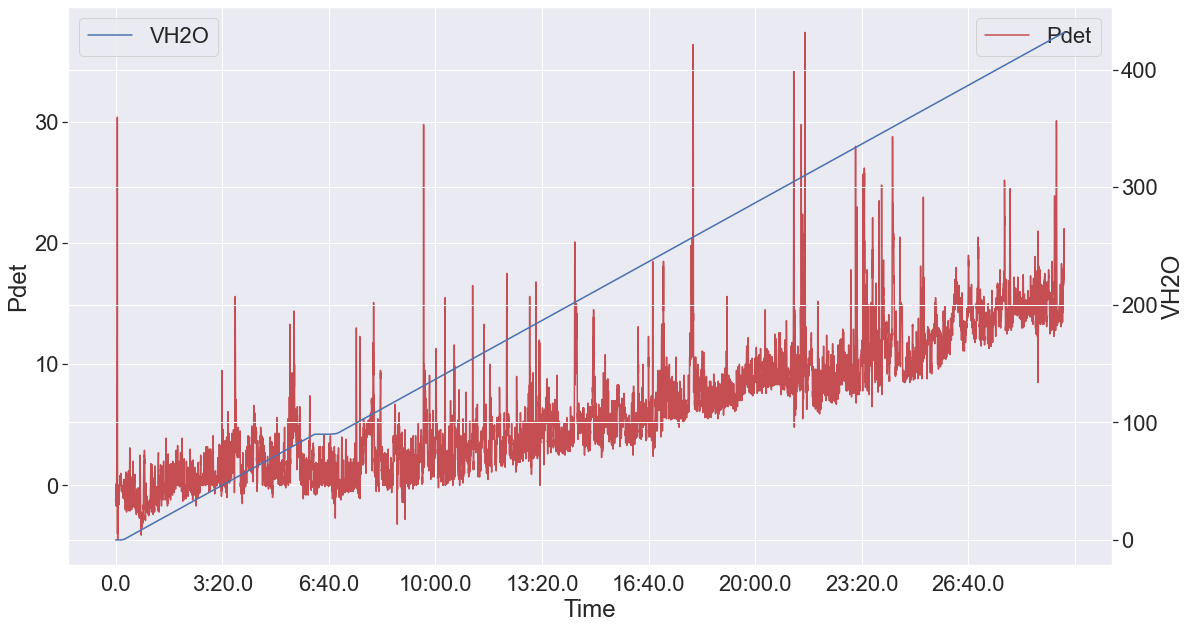

In [10]:

sns.set_style('whitegrid')
sns.set(font_scale = 2)
a4_dims = (18.7, 10.27)
ig, ax = plt.subplots(figsize=a4_dims)
axplt = sns.lineplot(x = "Time", y = 'Pdet', data = dftest,color="r",label = 'Pdet')
ax2 = plt.twinx()
sns.lineplot(x = "Time", y = 'VH2O', data = dftest, ax=ax2, color='b',label = 'VH2O')
axplt.xaxis.set_major_locator(ticker.MultipleLocator(2000))
plt.show()

In [11]:
dftest['bladercap'] = 400  ## The ebc for this paitent is 400
dftest['percent'] = dftest['VH2O']/dftest['bladercap'] ## Creating a new collumn for % ebc
dftest['percent']=dftest['percent'].round(2) ## rounding
dftest = dftest.loc[dftest['percent']>= 0.01]### Normalizing
dftest = dftest.loc[dftest['percent']<= 1.0]

In [15]:
df_time = dftest.loc[dftest['Time']== '10:00.0']

In [16]:
df_time

,Time,Pabd,Pves,IH2O,VH2O,Pdet,EMG2_A,bladercap,percent
6000,10:00.0,2.8,5.8,15.0,136.6,3.0,9.3,400,0.34


<b>This patient the percent ebc is 34% at 10 minutes

In [17]:
df_time = dftest.loc[dftest['Time']== '10:05.0']

In [18]:
df_time

,Time,Pabd,Pves,IH2O,VH2O,Pdet,EMG2_A,bladercap,percent
6050,10:05.0,2.8,6.1,15.0,137.9,3.2,9.5,400,0.34


In [19]:
dftest2 = dftest.groupby(['percent'])['Pdet','EMG2_A'].mean().reset_index()

<ipython-input-19-f4ab5d873cd4>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dftest2 = dftest.groupby(['percent'])['Pdet','EMG2_A'].mean().reset_index()


In [20]:
dftest2['percent'] = dftest2['percent'].round(2)

In [21]:
dftest2

,percent,Pdet,EMG2_A
0,0.01,-0.651282,8.958333
1,0.02,-1.545732,8.887195
2,0.03,-1.036538,8.860897
3,0.04,-0.530488,9.217073
4,0.05,0.238462,9.112821
...,...,...,...
95,0.96,13.386585,7.342073
96,0.97,14.339744,7.366026
97,0.98,14.412195,7.357317
98,0.99,13.142949,7.349359


<h2> Tracing file indexed by Bladder Capacity

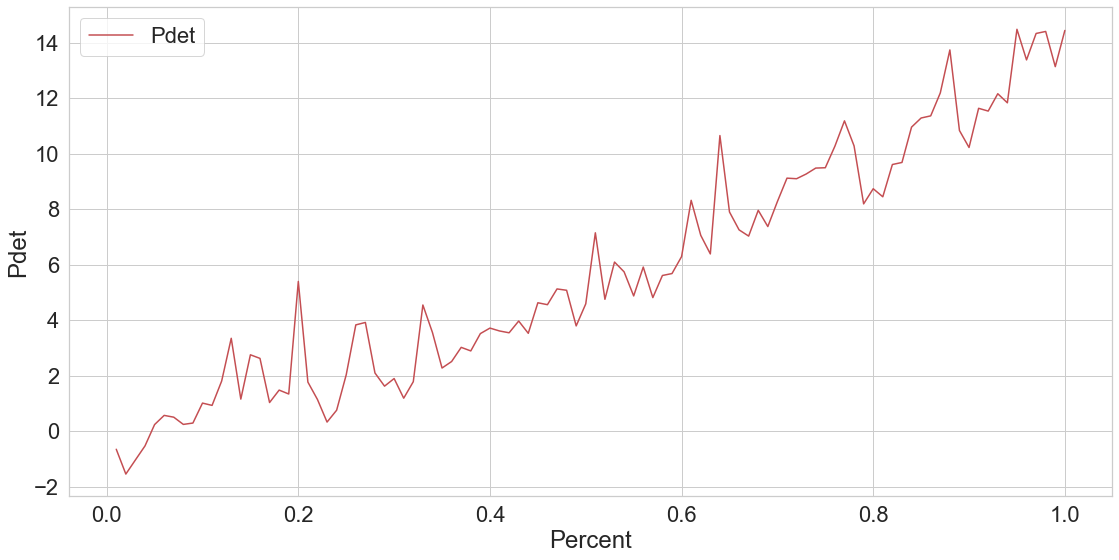

In [23]:
### By % fill
a4_dims = (18.7, 9)
sns.set(font_scale = 2)
sns.set_style('whitegrid')
ig, ax = plt.subplots(figsize=a4_dims)
Pabd = sns.lineplot(x = "percent", y = 'Pdet', data = dftest2,color="r",label = 'Pdet')
plt.xlabel("Percent")
plt.ylabel("Pdet")
plt.legend()
plt.show()


<h2>
    <center>Preparing the files for transformation: </center>
    <br>
1)	Open each text file in a directory<br>
2)	Finds the corresponding bladder capacity from the redcap spreadsheet<br>
3)	Calculate and averages percent limiting percent from 1 through 100<br>
4)	Return a list of normalized dataframes<br>
5)	Concatenate dataframes for train test split and cross validation<br>
6)	Maps ebc % at 10 minutes for each     


In [4]:
df1 = df[['study_id','exp_blad_cap']] ## the only columns from the flowsheet we need

In [8]:
file_dict={}

In [9]:
for i, row in df1.iterrows():
    file_dict.setdefault(row['study_id'],[])
    file_dict[row['study_id']].append(row['exp_blad_cap'])


In [10]:

df1 = df[['study_id','exp_blad_cap']]
for i, row in df1.iterrows():
    file_dict.setdefault(row['study_id'],[])
    file_dict[row['study_id']].append(row['exp_blad_cap'])

In [11]:
#### This function:
###### Opens each text file in a directory
#### Finds the corrosponding bladder cap from the redcap spreadsheet
### calculates and averages percent, limiting percent to 1 through 100
### Extracts the %fill at 10 minutes to compare with Boston model
### returns a list of normalized dataframes

def masterfile(files_txt):
    dflist = []
    percent_outer_list = []
    for file in files_txt:
        file2 = file.split('.')[0]
        for key, value in file_dict.items():
            if key == file2:
                dftest = pd.read_csv(file,sep='\t')
                dftest['bladercap'] = value[0]
                dftest['percent'] = dftest['VH2O']/dftest['bladercap']
                dftest['percent'] = dftest['percent'].round(2)
                dftest = dftest.loc[dftest['percent']>= 0.00]
                dftest = dftest.loc[dftest['percent']<= 1.0]
                df_time = dftest.loc[dftest['Time']== '10:00.0']
                for i, row in df_time.iterrows():
                    percent_list = []
                    percent_10 = row['percent']
                    percent_list.append(percent_10)
                    percent_outer_list.append(percent_list)
                dftest[['Pdet','percent']]
                dftest2 = dftest.groupby(['percent'])['Pdet'].mean().reset_index()
                del dftest2['percent']
                dftest3 = dftest2.transpose().reset_index()
                dftest3['Id'] = file2
                dflist.append(dftest3)
    return(dflist,percent_outer_list)                

In [12]:
dflistmasterlist,percent_outer_list = masterfile(files_txt)
dfpercent = pd.DataFrame(percent_outer_list, columns=['Percent_fill'])

<AxesSubplot:title={'center':'Distribution of Percent filled at 10 minutes'}>

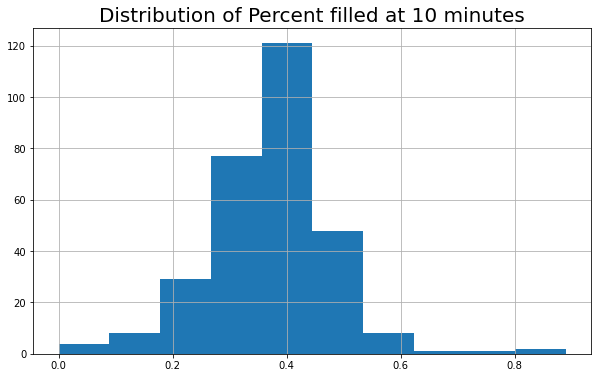

In [13]:
### Distribution of Percent filled at 10 minutes
plt.figure(figsize=(10,6))
plt.title("Distribution of Percent filled at 10 minutes",fontsize=20)
dfpercent["Percent_fill"].hist(bins=10)

<AxesSubplot:title={'center':'Distribution of Percent filled at 10 minutes'}, xlabel='Percent_fill', ylabel='Distribution'>

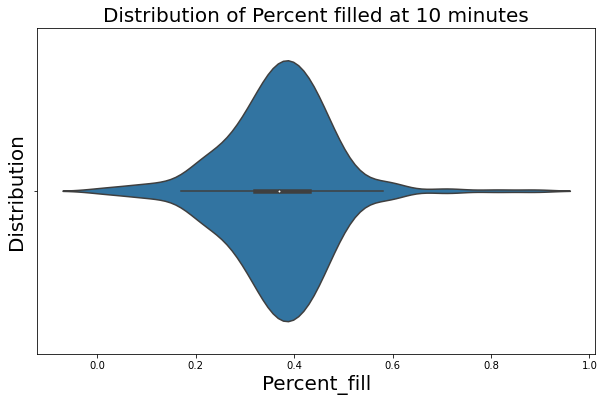

In [14]:
plt.figure(figsize=(10,6))
plt.title("Distribution of Percent filled at 10 minutes",fontsize=20)
plt.xlabel("Percent Fill",fontsize=20)
plt.ylabel("Distribution",fontsize=20)
sns.violinplot(x='Percent_fill',data=dfpercent)

In [13]:
df4 = pd.concat(dflistmasterlist) #Concatenate data frames 

In [46]:
df4.to_csv('firstpass6.csv')

In [6]:
# Read in data and display first 5 rows
reviews = pd.read_csv('ratings_master_all2.csv')
reviews.head()

,Study ID,Rating by Expert 1,Rating by Expert 2,Rating by Expert 3,Rating by Expert 4,Rating by Expert 5
0,VUDS-002,2.0,1.0,2.0,1.0,2.0
1,VUDS-004,1.0,NaN,2.0,NaN,2.0
2,VUDS-007,2.0,NaN,1.0,NaN,2.0
3,VUDS-009,3.0,NaN,3.0,NaN,NaN
4,VUDS-010,2.0,2.0,2.0,1.0,2.0


In [248]:
reviews.to_csv('revfinaluse.csv')

In [15]:
reviews['average_rating'] = reviews.loc[:,'Rating by Expert 1':'Rating by Expert 5'].mean(axis='columns',skipna=True).round(0)
reviews_hold = reviews[['Study ID','Rating by Expert 1','Rating by Expert 2','Rating by Expert 3','Rating by Expert 4','Rating by Expert 5']]

In [17]:
reviews = reviews[['Study ID','average_rating']]
reviews.head()

,Study ID,average_rating
0,VUDS-002,2.0
1,VUDS-004,2.0
2,VUDS-007,2.0
3,VUDS-009,3.0
4,VUDS-010,2.0


In [18]:
df2 = pd.merge(reviews,df4, how = "inner", left_on = 'Study ID',right_on = 'Id')

In [19]:
df2.head()

,Study ID,average_rating,index,0,1,2,3,4,5,6,...,92,93,94,95,Id,96,97,98,99,100
0,VUDS-002,2.0,Pdet,-0.077982,0.874123,1.477928,0.794595,0.472368,1.040541,0.973423,...,NaN,NaN,NaN,NaN,VUDS-002,NaN,NaN,NaN,NaN,NaN
1,VUDS-004,2.0,Pdet,0.641053,0.960714,1.074405,1.173718,1.375595,1.742262,1.642308,...,17.592857,8.192857,3.819231,7.755714,VUDS-004,6.939286,4.893846,7.747143,2.927143,2.603846
2,VUDS-007,2.0,Pdet,0.052632,0.274790,0.515833,0.388550,0.835833,1.212308,1.444167,...,NaN,NaN,NaN,NaN,VUDS-007,NaN,NaN,NaN,NaN,NaN
3,VUDS-009,3.0,Pdet,1.716940,2.002454,4.381169,2.828834,3.152147,2.931902,3.531818,...,NaN,NaN,NaN,NaN,VUDS-009,NaN,NaN,NaN,NaN,NaN
4,VUDS-010,2.0,Pdet,0.634400,1.205625,1.530000,1.460000,1.636250,1.916250,1.766875,...,12.761667,10.300833,8.874167,11.795000,VUDS-010,16.076667,13.060000,10.813333,13.147500,17.557031


In [20]:
del df2['index']
del df2['Id']

In [21]:
df2['average_rating'].value_counts()

2.0    146
1.0    103
3.0     41
Name: average_rating, dtype: int64

In [23]:
df3 = df2.iloc[:, :75]   ## adjust the percent here for example :25 :50

In [25]:
df3 = df3.dropna()

In [28]:
rev_master = pd.merge(reviews_hold,df3, how = "inner", left_on = 'Study ID',right_on = 'Study ID')

In [29]:
rev_master = rev_master[['Study ID','Rating by Expert 1','Rating by Expert 2','Rating by Expert 3','Rating by Expert 4','Rating by Expert 5']]

In [30]:
rev_master.tail()

,Study ID,Rating by Expert 1,Rating by Expert 2,Rating by Expert 3,Rating by Expert 4,Rating by Expert 5
282,VUDS-360,2.0,NaN,NaN,2.0,1.0
283,VUDS-361,NaN,NaN,NaN,2.0,2.0
284,VUDS-362,NaN,NaN,NaN,1.0,1.0
285,VUDS-279-2,NaN,NaN,NaN,1.0,1.0
286,VUDS-364,NaN,NaN,NaN,3.0,3.0


In [31]:
X = df3.iloc[:, 2:].reset_index()
del X['index']
y = df3.iloc[:, 1].reset_index()
del y['index']
y = y['average_rating'].values

In [292]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42,stratify = y)

In [ ]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()
x_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
x_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

In [44]:
num_classes = 3


<h2> Model, call backs to Ideal epics/ early stoppage/ validation set

In [261]:
def make_model(input_shape):
    input_layer = keras.layers.Input(input_shape)

    conv1 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(input_layer)
    conv1 = keras.layers.BatchNormalization()(conv1)
    conv1 = keras.layers.ReLU()(conv1)

    conv2 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(conv1)
    conv2 = keras.layers.BatchNormalization()(conv2)
    conv2 = keras.layers.ReLU()(conv2)

    conv3 = keras.layers.Conv1D(filters=64, kernel_size=3, padding="same")(conv2)
    conv3 = keras.layers.BatchNormalization()(conv3)
    conv3 = keras.layers.ReLU()(conv3)

    gap = keras.layers.GlobalAveragePooling1D()(conv3)

    output_layer = keras.layers.Dense(num_classes, activation="softmax")(gap)

    return keras.models.Model(inputs=input_layer, outputs=output_layer)


model = make_model(input_shape=x_train.shape[1:])


In [ ]:
epochs = 100
batch_size = 32


callbacks = [
    keras.callbacks.ModelCheckpoint(
        "best_model.h5", save_best_only=True, monitor="val_loss"
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=20, min_lr=0.0001
    ),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=50, verbose=1),
]
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)



In [780]:
class_weight_m = {0:0,1: 96, 2:109,3:3}

In [ ]:
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    
    validation_split=0.2,
    verbose=1,
)

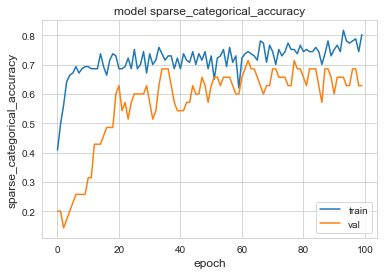

In [782]:
metric = "sparse_categorical_accuracy"
plt.figure()
plt.plot(history.history[metric])
plt.plot(history.history["val_" + metric])
plt.title("model " + metric)
plt.ylabel(metric, fontsize="large")
plt.xlabel("epoch", fontsize="large")
plt.legend(["train", "val"], loc="best")
plt.show()
plt.close()

In [39]:
from tensorflow.python.keras.models import Model, load_model

In [784]:
### model = load_model('best_model.h5') ## if you want to load/save a model

In [785]:
test_predictions = model.predict(x_test)

In [ ]:
##### Softmax
test_predictions = model.predict(x_test)
test_predictions.round(2)

In [66]:
model.save('goodmodel2.h5')  ## To save the model

In [76]:
Y = y

In [40]:
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import StratifiedKFold
import numpy

In [179]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
2.0    113
1.0    104
3.0     27

In [357]:
class_weight_m = {0:104,1: 113, 2:109,3:40}   ### class weights if needed for class imbalance

In [358]:
num_classes = 3

In [359]:
y[y == 1] = 0
y[y == 2] = 1
y[y == 3] = 2


<h3>5-K stratified cross validation

In [ ]:
kf = StratifiedKFold(n_splits=5,random_state=43, shuffle=True)
### To save metrics,predictions etc. 
acc_score = []
pred = []
y_test_all = []
test_pred_df = []
v_master_list = []
for train_index , test_index in kf.split(X,y):
    
    X_train1 , X_test1 = X.iloc[train_index,:],X.iloc[test_index,:]
    y_train1 , y_test1 = y[train_index] , y[test_index]
        
    X_train1 = X_train1.to_numpy()
    X_test1 = X_test1.to_numpy()

    X_train1 = X_train1.reshape((X_train1.shape[0], X_train1.shape[1], 1))
    X_test1 = X_test1.reshape((X_test1.shape[0], X_test1.shape[1], 1))
    model = make_model(input_shape=X_train1.shape[1:])
    
    model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
    )
    
    model.fit(
    X_train1,
    y_train1,
    batch_size=32,
    epochs=52,   
    #callbacks=callbacks,
    verbose=0,
    class_weight = class_weight_m   
    )
    test_predictions = model.predict(X_test1)
    predict_class = np.argmax(test_predictions, axis=1)
    predict_class = predict_class.tolist()
    
        
    test_predictions2 = pd.DataFrame(test_predictions)
    test_pred_df.append(test_predictions2)
    
    pred.append(predict_class)
    y_test_all.append(y_test1)
    print(model.evaluate(X_test1,y_test1, verbose=0))
    num = model.evaluate(X_test1,y_test1, verbose=0)
    #num = num.astype(float)
    acc_score.append(num)


for train_index , test_index in kf.split(rev_master,y):
    X_train1 , X_test1 = rev_master.iloc[train_index,:],rev_master.iloc[test_index,:]
    v_master_list.append(X_test1)

In [ ]:
f_score = []
for score in acc_score:
    f_score.append(score[1])
import statistics
acc = statistics.mean(f_score)    
acc  

<h2>Below, we are unpacking the results to get accuracy and confusion matrix for entire dataset

In [362]:
y_test_master = np.hstack(([y_test_all[0], y_test_all[1], y_test_all[2],y_test_all[3],y_test_all[4]]))
pred_master = np.hstack(([pred[0], pred[1], pred[2],pred[3],pred[4]]))
rate_master = pd.concat(v_master_list)
rate_master = rate_master.reset_index()
del rate_master['index']
pred_df = pd.DataFrame(pred_master, columns=['prediction'])
pred_df = pred_df.reset_index()
del pred_df['index']

In [331]:
rate_master['average_rating'] = rate_master.loc[:,'Rating by Expert 1':'Rating by Expert 5'].mean(axis='columns',skipna=True).round(0)

In [ ]:
df_rate_m = rate_master.merge(soft_pred_df, how='inner', left_index=True, right_index=True)



In [214]:
df_rate_m.to_csv('results.csv')

In [365]:
soft_pred_df = pd.concat(test_pred_df)
df_merged = pred_df.merge(rate_master, how='outer', left_index=True, right_index=True)



In [219]:
def agree(df):
    for i, row in df.iterrows():      
        if (pd.notnull(row['Rating by Expert 1'])and pd.notnull(row['Rating by Expert 2'])and
           pd.notnull(row['Rating by Expert 3'])and pd.notnull(row['Rating by Expert 4'])and
           pd.notnull(row['Rating by Expert 5'])):
            df.loc[i,'5_raters'] = 'Y'
        else:
            df.loc[i,'5_raters'] = 'N'           
        if(row['prediction'] == row['Rating by Expert 1'] or row['prediction'] == row['Rating by Expert 2']or row['prediction'] == row['Rating by Expert 3'] or row['prediction'] == row['Rating by Expert 4'] or row['prediction'] == row['Rating by Expert 5']):
            df.loc[i,'Some_agree'] = 'Y'
        else:
            df.loc[i,'Some_agree'] = 'N'
    return(df)                       

In [220]:
df_merged_final = agree(df_merged)

In [221]:
df_merged_five = df_merged_final[df_merged_final['5_raters']=='Y']

In [222]:
x = 44 + 6
print('Percent', 44/x)

Percent 0.88


In [224]:
df_merged_final.to_csv('pred.csv')

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score,accuracy_score

confusion = confusion_matrix(y_test_master, pred_master)
print('Confusion Matrix\n')
print(confusion)



In [128]:
df_merged_final['average_rating'] = df_merged_final.loc[:,'Rating by Expert 1':'Rating by Expert 5'].mean(axis='columns',skipna=True).round(0)

In [249]:
df_merged_final.head()

,prediction,Study ID,Rating by Expert 1,Rating by Expert 2,Rating by Expert 3,Rating by Expert 4,Rating by Expert 5,5_raters,Some_agree
0,1,VUDS-002,2.0,1.0,2.0,1.0,2.0,Y,Y
1,0,VUDS-004,1.0,NaN,2.0,NaN,2.0,N,N
2,0,VUDS-010,2.0,2.0,2.0,1.0,2.0,Y,N
3,0,VUDS-016,2.0,NaN,2.0,NaN,NaN,N,N
4,0,VUDS-030,1.0,NaN,2.0,NaN,1.0,N,N


In [130]:
df_merged_new = df_merged_final.merge(soft_pred_df, how='outer', left_index=True, right_index=True)



In [63]:
from sklearn.metrics import cohen_kappa_score

In [69]:
dfl['average_rating'] = dfl.loc[:,'Rating by Expert 1':'Rating by Expert 5'].mean(axis='columns',skipna=True).round(0)

In [75]:
dfl['prediction'] = dfl['prediction'].astype(float)

In [ ]:
from sklearn.metrics import cohen_kappa_score
rater1 = []
rater2 = []


for i, row in df_merged_final.iterrows():
    if pd.notnull(row['Rating by Expert 4']) and pd.notnull(row['Rating by Expert 3']):
        rater1.append(row['Rating by Expert 4'])
        rater2.append(row['Rating by Expert 3'])
cohen_kappa_score(rater1, rater2)

In [ ]:
### Kapa
pred = []
rater1 = []
for i, row in df_merged_final.iterrows():
    pred.append(row['prediction'])
    rater1.append(row['average_rating'])
labeler1 = rater1
labeler2 = pred
print('Kappa Model to predictions', cohen_kappa_score(labeler1, labeler2))    
    